In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import yaml

import sys, os
# This is not super pretty, but I think this is the best way to import stuff from ../../../util?
CODE_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if CODE_ROOT not in sys.path:
    sys.path.insert(1, CODE_ROOT)

from inference import initialize_trafo_from_saved_state, get_spectra_reference_point
from train_model import eval_model, collect_dataloaders
from plotting_functions import *

In [2]:
model_name = "sweep_model_100"

weights_path = f"../model_states/{model_name}_weights.pt"
config_path = f"../log_files/{model_name}_config.yaml"
plots_save_base_path = "../plots/"

with open(config_path) as f:
    params = yaml.safe_load(f)

suite_of_spectra = params['suite_of_spectra']

In [3]:
train_loader, eval_loader, test_loader, y_mean, y_std = collect_dataloaders(config_path)

In [4]:
len_in = test_loader.dataset.X.shape[1]
len_out = test_loader.dataset.y.shape[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, criterion, optimizer = initialize_trafo_from_saved_state(config_path, len_in, len_out, weights_path, device)

In [5]:
# note: this takes about 7 minutes on cpu
_, y_test_true, y_test_pred = eval_model(model, test_loader, criterion, device, return_predictions=True)
y_test_true, y_test_pred  = y_test_true*y_std + y_mean, y_test_pred*y_std + y_mean
y_true, y_pred = y_test_true.numpy(), y_test_pred.numpy()

/u/jerbo/CLIMB-Project/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


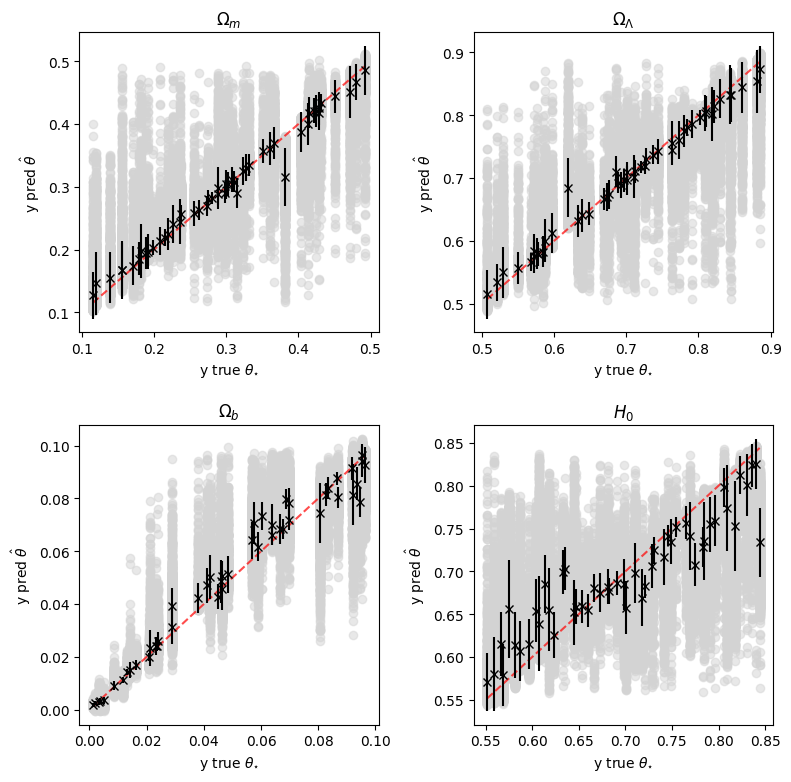

In [6]:
save_path = plots_save_base_path + f"{model_name}_errorbars.pdf"
plot_test_inference_errorbars(y_true, y_pred, save_path, save_plot=True)

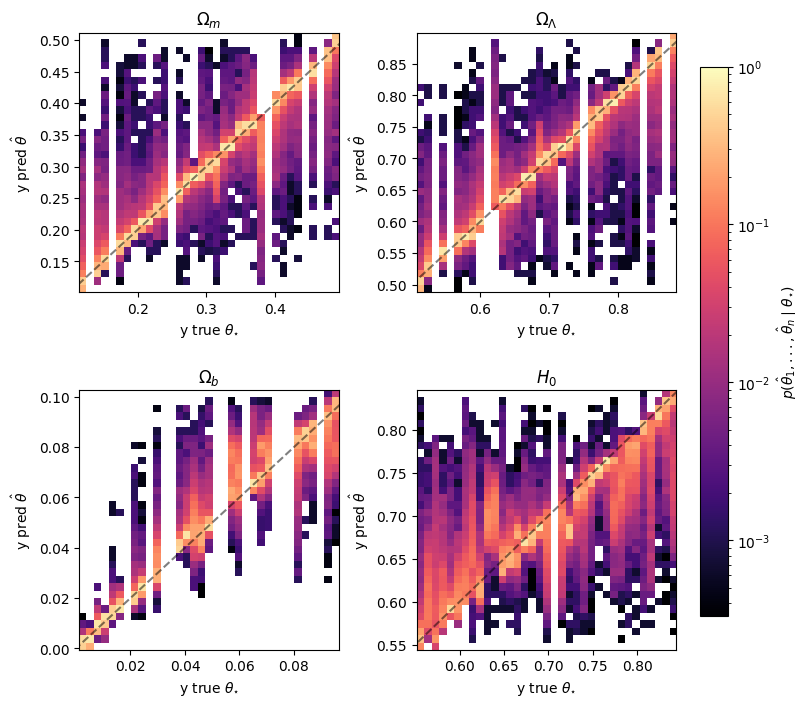

In [7]:
save_path = plots_save_base_path + f"{model_name}_colors.pdf"
plot_test_inference_colors(y_true, y_pred, save_path, save_plot=True)

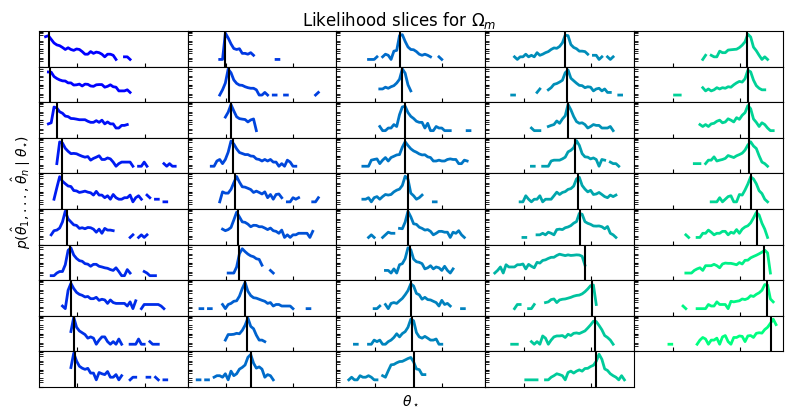

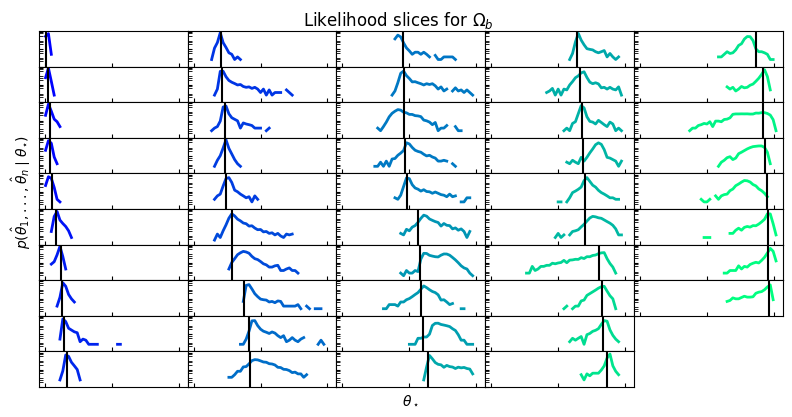

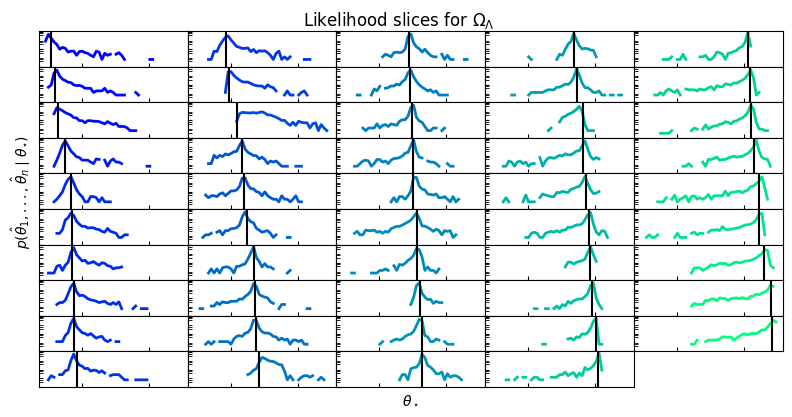

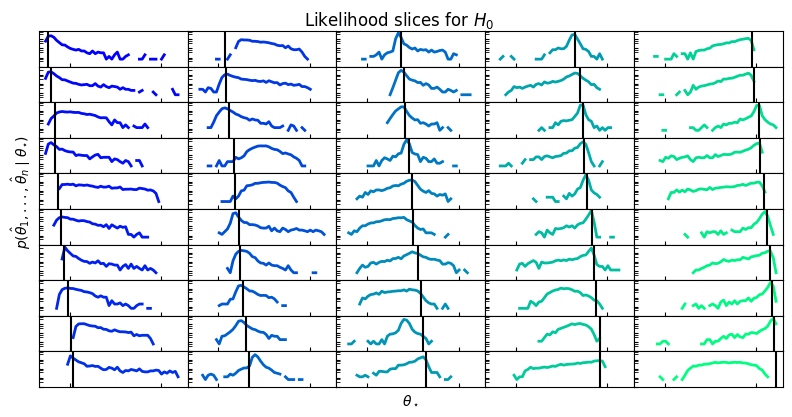

In [8]:
save_path = "/vera/u/jerbo/CLIMB-Project/code/Machine_Learning/Transformer_pipeline/plots/" + f"{model_name}_PDF.pdf"
plot_all_PDFs(y_true, y_pred, save_path, save_plot=True)

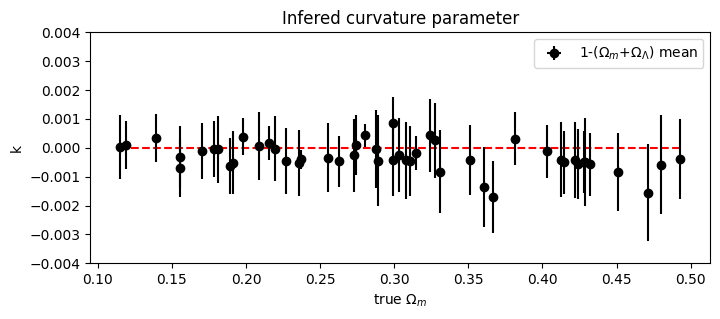

In [9]:
save_path = plots_save_base_path + f"{model_name}_curvature.pdf"
plot_curvature_param(y_true, y_pred, save_path, save_plot=True)

In [10]:
def predict_loader(model, X, device, batch_size=128):
    loader = DataLoader(TensorDataset(X), batch_size=batch_size)
    preds = []

    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu())

    return torch.cat(preds)

In [11]:
ref_box_specs, _ = get_spectra_reference_point(suite_of_spectra, n_spectra=10000)
ref_box_specs = torch.Tensor(ref_box_specs)

In [12]:
# note: this takes about a minute on cpu
y_pred_ref = predict_loader(model, ref_box_specs, device)

y_pred_ref = y_pred_ref*y_std + y_mean
y_pred_ref = y_pred_ref.numpy()

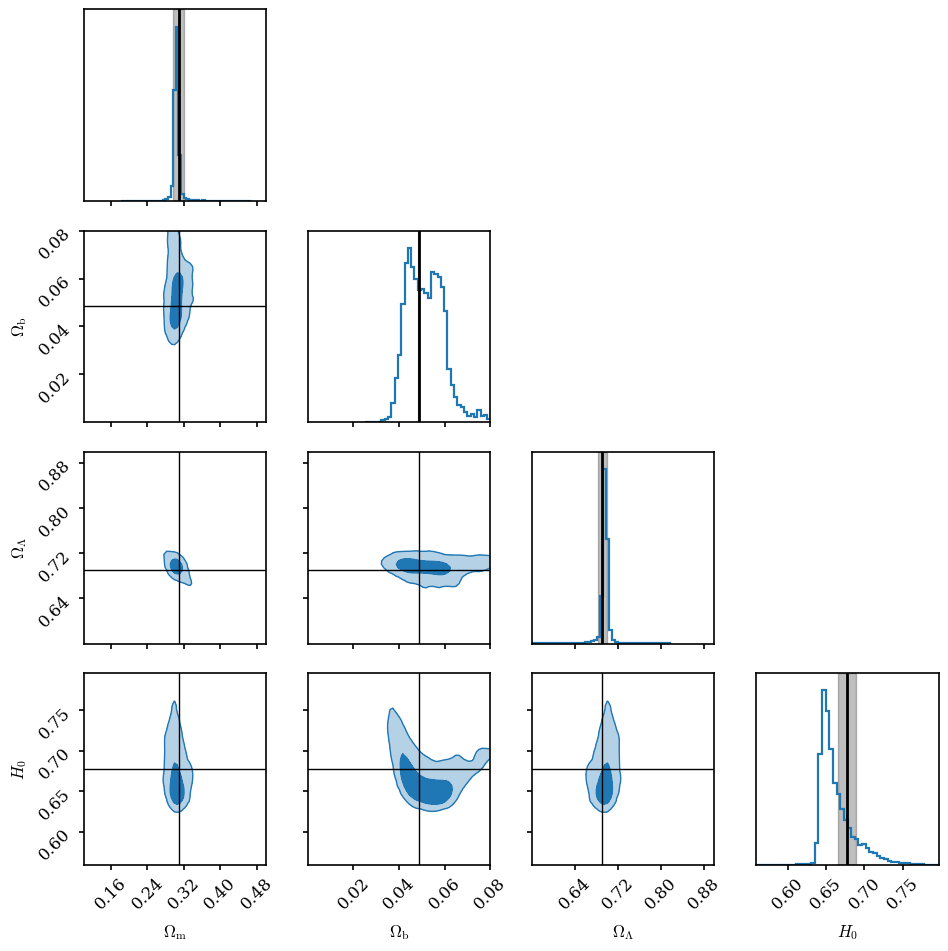

In [ ]:
# make_corner_plot(y_pred_ref, "ref_corner_path", False)

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D


def _kde_2d(x, y, gridsize=200, bw_scale=0.5, bounds=None):
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    kde.covariance_factor = lambda: kde.scotts_factor() * bw_scale
    kde._compute_covariance()

    if bounds is None:
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
    else:
        xmin, xmax, ymin, ymax = bounds

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, gridsize),
        np.linspace(ymin, ymax, gridsize)
    )
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    return xx, yy, zz


def _credible_threshold(density, level=0.68):
    z = density.ravel()
    idx = np.argsort(z)[::-1]
    z_sorted = z[idx]
    cdf = np.cumsum(z_sorted)
    cdf /= cdf[-1]
    return z_sorted[np.searchsorted(cdf, level)]


def make_corner_plot_custom(
    y_preds,
    labels,
    model_names=None,
    axis_limits=None,
    planck=None,
    planck_err=None,
    planck_color="#333333",
    bw_scale=0.4,
    fill_alpha=0.5,
    gridsize=180,
    bins=50,
    show_2sigma=False,
    figsize=(8, 8),
    fill_colors=None,
    edge_colors=None,
    save_path=None,
    show_plot=True
):

    n_dim = y_preds[0].shape[1]

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(n_dim, n_dim, figure=fig, wspace=0.0, hspace=0.0)

    axes = np.empty((n_dim, n_dim), dtype=object)

    for i in range(n_dim):
        for j in range(n_dim):

            if i < j:
                axes[i, j] = None
                continue

            sharex = axes[n_dim - 1, j] if i < n_dim - 1 else None
            sharey = axes[i, 0] if (i != j and j > 0) else None

            axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex, sharey=sharey)
    if fill_colors is None:
        fill_colors = ["#63a5d4", "#de7171", "#6fd66f", "#cfa2f8", "#ffa556"]
    if edge_colors is None: 
        edge_colors = ["#176395", "#a90c0c", "#199b3c", "#4b0082", "#8c3f00"]

    for i in range(n_dim):
        for j in range(n_dim):

            ax = axes[i, j]
            if ax is None:
                continue

            for k, samples in enumerate(y_preds):

                color = fill_colors[k % len(fill_colors)]
                edge = edge_colors[k % len(edge_colors)]

                if i == j:

                    data = samples[:, i]

                    if axis_limits and axis_limits[i] is not None:
                        xmin, xmax = axis_limits[i]
                        data = data[(data >= xmin) & (data <= xmax)]
                        hist_range = (xmin, xmax)
                    else:
                        hist_range = None

                    ax.hist(
                        data,
                        bins=bins,
                        range=hist_range,
                        density=True,
                        histtype="step",
                        linewidth=1.4,
                        color=color
                    )

                    if planck is not None:
                        ax.axvline(planck[i], color=planck_color, lw=1.0, linestyle="--", zorder=5)
                        ax.axvspan(
                            planck[i] - planck_err[i],
                            planck[i] + planck_err[i],
                            color=planck_color,
                            alpha=0.2,
                            zorder=5
                        )

                    ax.tick_params(labelleft=False)

                else:

                    x = samples[:, j]
                    y = samples[:, i]

                    bounds = None
                    if axis_limits and axis_limits[i] is not None:
                        xmin, xmax = axis_limits[j]
                        ymin, ymax = axis_limits[i]
                        bounds = (xmin, xmax, ymin, ymax)

                    xx, yy, zz = _kde_2d(x, y, gridsize, bw_scale, bounds)

                    thr_1 = _credible_threshold(zz, 0.68)

                    if show_2sigma:
                        thr_2 = _credible_threshold(zz, 0.95)

                        ax.contourf(
                            xx, yy, zz,
                            levels=[thr_2, zz.max()],
                            colors=[color],
                            alpha=fill_alpha * 0.5
                        )

                    ax.contourf(
                        xx, yy, zz,
                        levels=[thr_1, zz.max()],
                        colors=[color],
                        alpha=fill_alpha
                    )

                    ax.contour(
                        xx, yy, zz,
                        levels=[thr_1],
                        colors=[edge],
                        linewidths=1.5,
                    )

                    if show_2sigma:
                        ax.contour(
                            xx, yy, zz,
                            levels=[thr_2],
                            colors=[edge],
                            linewidths=1.0,
                            # linestyles="dashed"
                        )

                    if planck is not None:
                        ax.axvline(planck[j], color=planck_color, lw=1.0, linestyle="--")
                        ax.axhline(planck[i], color=planck_color, lw=1.0, linestyle="--")

            if axis_limits:
                if i == j:
                    ax.set_xlim(axis_limits[i])
                else:
                    ax.set_xlim(axis_limits[j])
                    ax.set_ylim(axis_limits[i])

            ax.tick_params(direction="in", top=True, right=True)

            if j == 0 and i != j:
                ax.tick_params(labelleft=True)
                ax.set_ylabel(labels[i])
            elif j != 0:
                ax.tick_params(labelleft=False)

            if i == n_dim - 1:
                ax.set_xlabel(labels[j])
            else:
                ax.tick_params(labelbottom=False)

    if model_names is not None:

        legend_elements = [
            Patch(
                facecolor=fill_colors[i],
                edgecolor=edge_colors[i],
                label=model_names[i],
                alpha=fill_alpha
            )
            for i in range(len(model_names))
        ]

        legend_elements.append(
            Line2D(
                [0], [0],
                color="black",
                linestyle="--",
                linewidth=1.3,
                label="Planck 2015"
            )
        )

        anchor_x = (n_dim - 0.5) / n_dim
        anchor_y = (n_dim - 0.5) / n_dim

        fig.legend(
            handles=legend_elements,
            loc="center",
            bbox_to_anchor=(anchor_x, anchor_y),
            frameon=False
        )

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    if show_plot:
        plt.show()

    plt.close()

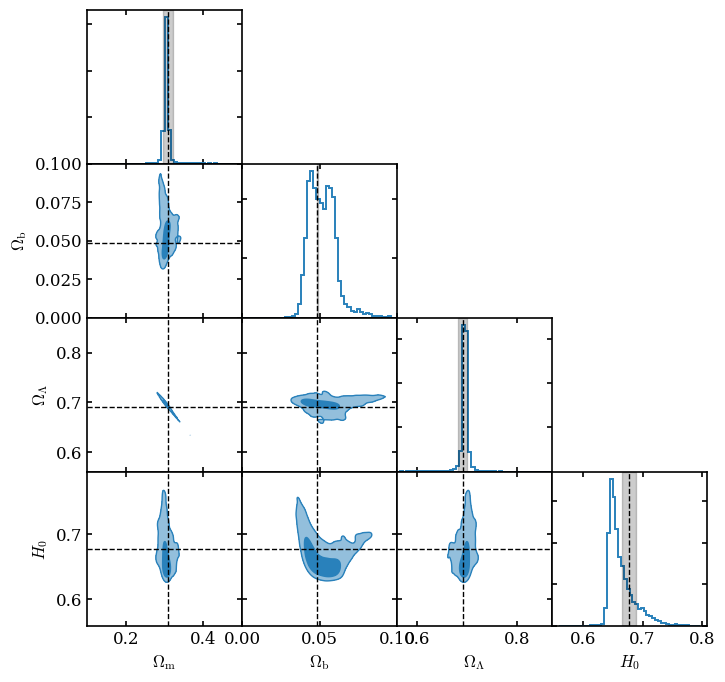

In [40]:
save_path = plots_save_base_path + f"{model_name}_refbox_cornerplot.pdf"

axis_limits = [
        (0.1, 0.5),
        (0, 0.1),
        (0.56, 0.87),
        None
    ]

colors = ["#2981BB", "#a90c0c", "#199b3c", "#4b0082", "#8c3f00"]

make_corner_plot_custom(
    [y_pred_ref],

    labels=[
        r"$\Omega_{\mathrm{m}}$",
        r"$\Omega_{\mathrm{b}}$",
        r"$\Omega_{\Lambda}$",
        r"$H_0$"
    ],

    # model_names=["Teset"],

    axis_limits=axis_limits,

    planck=np.array([0.3089, 0.0486, 0.6911, 0.6774]),
    planck_err=np.array([0.012, 2.2e-4, 0.009, 0.012]),

    bw_scale=1,   # lower = sharper contours
    fill_alpha=1,
    gridsize=250,
    bins=50,
    figsize=(8,8),
    planck_color="#000000",
    fill_colors=colors,
    edge_colors=colors,
    show_2sigma=True,

    save_path=save_path
)